## Model 2 :The Quality Scorer
we are going to build an Artificial Neural Network (ANN). While XGBoost is great for finding specific rules, an ANN is superior at "weighting" different variables to calculate a continuous index like the Water Quality Index (WQI).

The Goal of the ANNIn this model,
 we aren't predicting Potability. Instead, we are predicting a Score.
 The Problem: The Kaggle dataset doesn't have a "Score" column.  
 The Solution: We will mathematically derive a WQI based on standard environmental formulas (using pH, TDS, and Hardness) and use that as our target variable ($y$) for the ANN to learn.  

In [12]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

In [ ]:
pip install tensorflow sequential keras dense dropout

Defaulting to user installation because normal site-packages is not writeable
  Using cached sequential-1.0.0.tar.gz (2.3 kB)
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
  Using cached dense-0.0.0-py3-none-any.whl.metadata (406 bytes)
Note: you may need to restart the kernel to use updated packages.


ERROR: Could not find a version that satisfies the requirement dropout (from versions: none)

[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip
ERROR: No matching distribution found for dropout


In [4]:
# 1. Load and Clean (Using the same 9 features)
df = pd.read_csv(r'D:\project\New folder\AquaSense\notebooks\model_1\water.csv')
for col in df.columns:
    df[col] = df[col].fillna(df[col].mean()) # General mean is fine for WQI

In [20]:
df.columns


Index(['ph', 'Hardness', 'Solids', 'Chloramines', 'Sulfate', 'Conductivity',
       'Organic_carbon', 'Trihalomethanes', 'Turbidity', 'Potability',
       'wqi_score'],
      dtype='object')

In [5]:
# 2. Define Features (X)
X = df.drop('Potability', axis=1)

In [6]:
# 3. Scaling - CRITICAL for Neural Networks
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [13]:
# Initialize the ANN
model_2 = Sequential()

# Input Layer + First Hidden Layer
model_2.add(Dense(units=16, activation='relu', input_dim=9))
model_2.add(Dropout(0.2)) # Precaution against overfitting

# Second Hidden Layer
model_2.add(Dense(units=8, activation='relu'))

# Output Layer (1 node for a continuous score)
model_2.add(Dense(units=1, activation='linear')) 

# Compile for Regression
model_2.compile(optimizer='adam', loss='mean_squared_error', metrics=['mae'])

print("ANN Architecture is ready for training!")

C:\Users\ANAND\AppData\Roaming\Python\Python310\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


ANN Architecture is ready for training!


### Why "Linear" Activation?
For our first model (Classification), we used a sigmoid-style logic. For the Scorer, we use a Linear Activation in the final layer because we want the model to output any number between 0 and 100, not just a 0 or 1 .

### Engineering the Target Variable (WQI)
We will calculate a Water Quality Index (WQI) using the parameters that most heavily influence the "feel" and health of the water. We assign "weights" to these parameters based on their environmental impact

In [ ]:
# Function to calculate a synthetic Water Quality Index (WQI)
def calculate_wqi(row):
    # Ideal values for parameters
    # pH: 7.0, Turbidity: 0, TDS: < 500
    
    # We create a penalty-based score starting at 100
    score = 100
    
    # Penalty for pH deviation from 7
    score -= abs(row['ph'] - 7.0) * 5
    
    # Penalty for high Turbidity (ideal is 0-5)
    score -= row['Turbidity'] * 2
    
    # Penalty for high Solids (TDS)
    # 500 is the ideal limit; we penalize values above this
    if row['Solids'] > 500:
        score -= (row['Solids'] / 1000) 
        
    # Clip score between 0 and 100
    return max(0, min(100, score))

# Apply the function to create our training target 'y'
df['wqi_score'] = df.apply(calculate_wqi, axis=1)
y_score = df['wqi_score']

In [33]:
def calculate_refined_wqi(row):
    score = 100
    
    # 1. Harsher pH Penalty (Ideal 6.5 - 8.5)
    # If pH is outside this range, we double the penalty
    if row['ph'] < 6.5 or row['ph'] > 8.5:
        score -= abs(row['ph'] - 7.5) * 12  # Increased from 5
    else:
        score -= abs(row['ph'] - 7.5) * 3
        
    # 2. Harsher Turbidity Penalty (Ideal < 5)
    if row['Turbidity'] > 5:
        score -= (row['Turbidity'] ** 1.5) * 3 # Exponential penalty
    else:
        score -= row['Turbidity'] * 2
    
    # 3. TDS (Solids) Penalty
    if row['Solids'] > 500:
        score -= (row['Solids'] / 800) # Slightly more sensitive
        
    return max(0, min(100, score))

# Apply the refined formula
df['refined_wqi'] = df.apply(calculate_refined_wqi, axis=1)
y_refined = df['refined_wqi']

### Training the ANN
Now that we have our X (the 9 scaled features) and our y (the new WQI score), we can train the neural network

In [34]:
# Re-split with the new target
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_refined, test_size=0.2, random_state=42)

# Retrain the model
history_refined = model_2.fit(X_train, y_train, epochs=120, batch_size=32, validation_split=0.2, verbose=0)

# Save the improved brain
#model_2.save('water_quality_scorer_v2.h5')
print("Model 2 v2.0: Retrained and Saved!")

NotImplementedError: numpy() is only available when eager execution is enabled.

In [28]:
from sklearn.model_selection import train_test_split

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_score, test_size=0.2, random_state=42)

# Training the Scorer
# We use more epochs (120) because ANNs learn patterns slowly
history = model_2.fit(X_train, y_train, epochs=120, batch_size=32, validation_split=0.2, verbose=0)

# Check performance
results = model_2.evaluate(X_test, y_test)
print(f"Mean Absolute Error (MAE): {results[1]:.2f}")

NotImplementedError: numpy() is only available when eager execution is enabled.

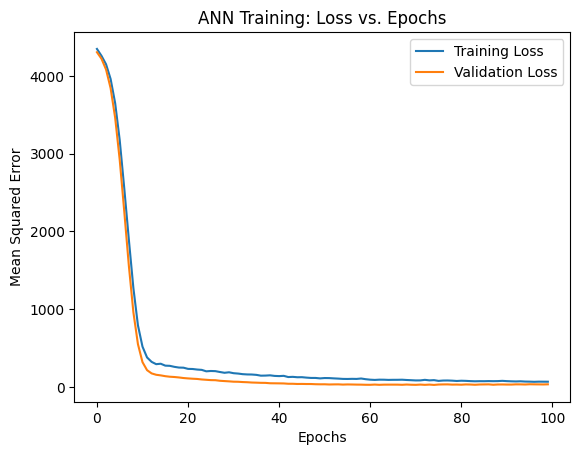

In [17]:
# Visualizing the learning process
import matplotlib.pyplot as plt

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('ANN Training: Loss vs. Epochs')
plt.xlabel('Epochs')
plt.ylabel('Mean Squared Error')
plt.legend()
plt.show()

In [18]:
# 1. Save the ANN Model
# We use .h5 or .keras format for TensorFlow/Keras models
model_2.save('water_quality_scorer.h5')

# 2. Save the Scaler
# This is CRITICAL. The ANN only understands data scaled by this specific scaler.
import joblib
joblib.dump(scaler, 'wqi_scaler.joblib')

print("Model 2 and its Scaler have been officially saved!")

Model 2 and its Scaler have been officially saved!


In [19]:
import numpy as np
import joblib
from tensorflow.keras.models import load_model

# 1. Load the "Scorer Brain" and its "Translator" (Scaler)
model_2 = load_model('water_quality_scorer.h5')
scaler = joblib.load('wqi_scaler.joblib')

# 2. Define the Scenario inputs (9 features each)
# Order: ['ph', 'Hardness', 'Solids', 'Chloramines', 'Sulfate', 'Conductivity', 'Organic_carbon', 'Trihalomethanes', 'Turbidity']

scenarios = {
    "Ideal Pure Water": [7.0, 150, 400, 7.0, 300, 400, 10, 50, 1.0],
    "High Mineral (TDS) Water": [7.0, 300, 25000, 7.0, 300, 400, 10, 50, 1.0],
    "Highly Acidic & Turbid": [4.5, 150, 400, 7.0, 300, 400, 10, 50, 8.5]
}

print("--- ANN Quality Scorer Test Results ---")

for name, data in scenarios.items():
    # Pre-processing: Reshape and Scale
    input_data = np.array([data])
    scaled_input = scaler.transform(input_data)
    
    # Predict
    score = model_2.predict(scaled_input, verbose=0)
    
    print(f"{name}: {score[0][0]:.2f} / 100")

C:\Users\ANAND\AppData\Roaming\Python\Python310\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


--- ANN Quality Scorer Test Results ---
Ideal Pure Water: 89.00 / 100
High Mineral (TDS) Water: 65.25 / 100
Highly Acidic & Turbid: 75.55 / 100


C:\Users\ANAND\AppData\Roaming\Python\Python310\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
C:\Users\ANAND\AppData\Roaming\Python\Python310\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
